In [1]:
from src.misc import *
from src.SPECTRUM import Spectrum
from src.FITSPECTRUM import FitSpectrum
from src.DP import DP
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
import pandas as pd

In [2]:
hsc_fits_1 = fits.open('~/Downloads/GAMA15h.fits')
hsc_fits_1.info()

Filename: /Users/hyp0515/Downloads/GAMA15h.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU     44   3524912R x 18C   [D, D, K, E, E, D, D, D, D, D, D, E, E, J, L, E, E, E]   


In [3]:
hsc_fits_2 = fits.open('~/Downloads/WIDE12h.fits')
hsc_fits_2.info()

Filename: /Users/hyp0515/Downloads/WIDE12h.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU     44   10003258R x 18C   [D, D, K, E, E, D, D, D, D, D, D, E, E, J, L, E, E, E]   


In [4]:
hsc_df_1 = Table(hsc_fits_1[1].data).to_pandas()
hsc_df_2 = Table(hsc_fits_2[1].data).to_pandas()
hsc_df = pd.concat([hsc_df_1, hsc_df_2], ignore_index=True)
hsc_df = hsc_df[['i_ra', 'i_dec', 'i_hsmshaperegauss_e1', 'i_hsmshaperegauss_e2']].copy()
hsc_df.head(10)

,i_ra,i_dec,i_hsmshaperegauss_e1,i_hsmshaperegauss_e2
0,207.467906,-1.675743,0.375279,-0.491569
1,207.470322,-1.673386,0.425460,0.666496
2,207.462696,-1.670700,0.122126,0.088257
3,207.456166,-1.670038,-1.220727,-1.219166
4,207.461852,-1.666839,0.493167,-0.244497
5,207.472146,-1.665931,-0.451673,-0.173955
6,207.472255,-1.663710,0.297540,-0.374590
7,207.456082,-1.663141,-0.908269,-0.302132
8,207.454793,-1.659580,-0.061594,0.384789
9,207.456909,-1.658780,0.268305,0.740619


In [5]:
print(len(hsc_df))

13528170


In [6]:
from scipy.spatial import KDTree

# Create a KDTree for fast spatial queries on the HSC dataframe
# Note: We only need to do this once.
hsc_coords = np.c_[hsc_df['i_ra'], hsc_df['i_dec']]
hsc_tree = KDTree(hsc_coords)

def find_all_matches(spectra_df, hsc_df, hsc_tree, search_radius_deg=0.001):
    """
    Finds the closest match in hsc_df for each object in spectra_df using a KDTree.
    """
    # Get coordinates from the spectra dataframe
    spectra_coords = np.c_[spectra_df['RA'], spectra_df['DEC']]
    
    # Query the tree to find the nearest neighbor for each spectrum object
    # It returns the distance and the index of the neighbor in hsc_df
    distances, indices = hsc_tree.query(spectra_coords, k=1)

    # Convert search radius from degrees to the squared distance used by the tree
    # This is a good approximation for small angular separations.
    max_distance = search_radius_deg
    
    # Filter out matches that are outside the search radius
    valid_indices_mask = distances < max_distance

    # Get the indices from hsc_df for valid matches
    matched_hsc_indices = indices[valid_indices_mask]

    # Create a new dataframe with the matched morphological data
    matched_df = hsc_df.iloc[matched_hsc_indices].copy()

    # Get the corresponding data from the spectra dataframe to merge
    matched_spectra_df = spectra_df[valid_indices_mask].copy()
    
    # Reset indices to allow for a clean merge
    matched_df.reset_index(drop=True, inplace=True)
    matched_spectra_df.reset_index(drop=True, inplace=True)
    
    # Combine the dataframes side-by-side
    # This merges the original spectra info with the new morphology info
    result_df = pd.concat([matched_spectra_df, matched_df], axis=1)
    # result_df.drop(columns=['catalog_version', 'legacy_survey_data_release', 'brickid', 'objid', 'brickid'], errors='ignore', inplace=True)
    # result_df.drop(columns=['SPECTYPE', 'FLUX_G', 'FLUX_R', 'FLUX_Z', 'z_pipe'], errors='ignore', inplace=True)
    return result_df

In [7]:
dps_fits = fits.open('./catalogs/dps_classified.fits')
dps_df = Table(dps_fits[1].data).to_pandas()

In [8]:
# dps_df[['TARGETID', 'RA', 'DEC']].to_csv('./catalogs/dp_catalog_test.csv', index=False)

In [9]:
matched_df = find_all_matches(dps_df, hsc_df, hsc_tree, search_radius_deg=0.001)
matched_df.head(10)

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,dv_r,dv_l,sigma_r,sigma_l,...,Halpha_rank,NII6583_rank,SII6716_rank,SII6731_rank,dp_count,BPT_class,i_ra,i_dec,i_hsmshaperegauss_e1,i_hsmshaperegauss_e2
0,39627745486967363,181.241364,-1.625736,0.285126,10.099066,0.985086,27.818142,-26.991318,16.050646,73.528221,...,0,1,7,8,5,2,181.241373,-1.625725,-0.131298,0.141964
1,39627745507939243,182.477997,-1.646495,0.225397,10.556316,1.291863,120.203278,-73.092041,85.180420,64.467545,...,0,1,3,4,6,2,182.478010,-1.646484,-0.222037,-0.167651
2,39627745507939364,182.483276,-1.653498,0.198040,10.284588,-0.146959,64.813538,-47.854057,32.838539,45.384346,...,0,1,2,3,2,512,182.483267,-1.653495,-0.095361,0.323919
3,39627745512129123,182.527313,-1.640771,0.081015,9.275529,-0.795147,82.737762,-16.887877,1.733871,35.433315,...,0,1,2,4,1,272,182.527332,-1.640791,-0.680233,-0.534608
4,39627745705072290,194.238281,-1.640867,0.226168,10.615349,1.501379,39.578022,-101.437889,170.413742,53.604828,...,0,1,4,6,1,272,194.238286,-1.640859,0.207776,0.210454
5,39627745931560454,207.583664,-1.629977,0.205783,10.397064,0.627712,42.109928,-96.025459,55.494629,37.112068,...,0,1,4,2,1,512,207.583665,-1.629972,0.082871,-0.099291
6,39627745931560563,207.589340,-1.645088,0.204461,10.220044,1.308577,79.252602,-60.430042,64.324005,41.065216,...,0,1,2,4,5,2,207.589341,-1.645083,0.555122,0.281977
7,39627746099332340,217.557526,-1.641927,0.242378,9.570164,1.685416,59.511654,-39.262001,30.323561,37.250301,...,0,1,4,7,2,512,217.557523,-1.641946,0.285575,0.034123
8,39627746099333588,217.613052,-1.644510,0.241284,10.647462,0.221903,70.878525,-13.384675,0.010000,47.796284,...,0,1,4,8,2,257,217.613042,-1.644509,-0.071552,0.020912
9,39627746187413154,222.810760,-1.632049,0.144618,10.273993,0.786957,49.142948,-100.319221,78.873734,35.208542,...,0,1,2,5,3,2,222.810752,-1.632050,-0.670637,-0.013147


In [10]:
print(len(matched_df))

11898


In [11]:
b_a_ratio = np.sqrt((1-np.sqrt(matched_df['i_hsmshaperegauss_e1']**2 + matched_df['i_hsmshaperegauss_e2']**2)) /\
    (1+np.sqrt(matched_df['i_hsmshaperegauss_e1']**2 + matched_df['i_hsmshaperegauss_e2']**2)))
matched_df['incl'] = np.arccos(b_a_ratio) * 180 / np.pi

/opt/anaconda3/envs/master_project/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [12]:
matched_df[['TARGETID', 'incl']].sort_values(by='incl', ascending=False).head(20)

,TARGETID,incl
2165,39627764059341579,81.948311
3106,39627769872648137,81.923088
8424,39627799874508747,81.721886
5306,39627781851581590,81.676933
369,39627752168490115,81.437950
9815,39627806132409057,81.404350
7961,39627794329634984,81.339920
10491,39627811928936262,81.324310
7998,39627794354801827,81.318863
5103,39627781750919925,81.152008


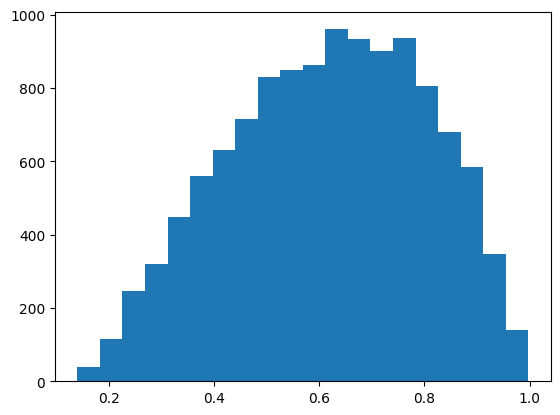

In [13]:
plt.hist(b_a_ratio, bins=20)
plt.show()

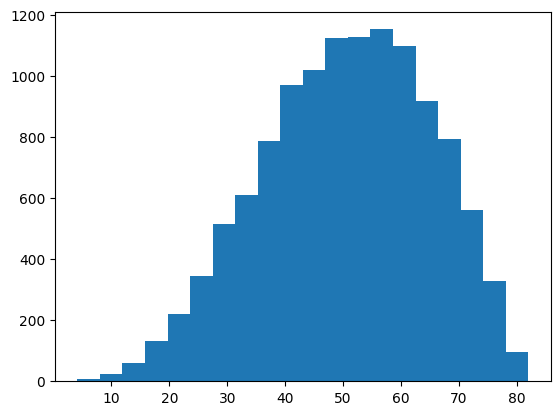

In [14]:
plt.hist(matched_df['incl'], bins=20)
plt.show()

In [15]:
matched_df[['TARGETID', 'incl']].to_csv('./catalogs/dp_catalog_with_inclination.csv', index=False)
